In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
t_values = [0, 1, 1, 1, 0, 0, 0, 1] # true values
p_values = [0, 1, 0, 1, 0, 1, 0, 0] # predicted values

In [30]:
class Smth:
    def __init__(this):
        this.tp = 0
        this.tn = 0
        this.fp = 0
        this.fn = 0
    # tp = int
    # tn = int
    # fp = int
    # fn = int
    def show(this):
        print("tp:", this.tp)
        print("tn:", this.tn)
        print("fp:", this.fp)
        print("fn:", this.fn)

def calculateValues(_t_values, _p_values):
    arr = [[0, 0], [0, 0]]
    smth = Smth()
    
    # print(_t_values, _p_values)
    
    for x, y in zip(_t_values, _p_values):
        if x == 0:
            if y == 0:
                arr[1][0] += 1
                smth.tn += 1
            else:
                arr[0][1] += 1
                smth.fp += 1
        else:
            if y == 1:
                arr[1][1] += 1
                smth.tp += 1
            else:
                arr[0][0] += 1
                smth.fn += 1
    
    # smth.show()
    
    return smth

def accuracy(smth):
    return (smth.tp + smth.tn) / (smth.tp + smth.tn + smth.fp + smth.fn)

def precision(smth): # ile z przewidzianych wartosci na True zostalo poprawnie przewidzianych
    return smth.tp / (smth.tp + smth.fp)

def recall(smth): # przyklad z chorobami (nie moze byc, ze ktos nie ma choroby, a w rzeczywistosci ma)
    return smth.tp / (smth.tp + smth.fn)

def accuracy2(_arr):
    return (_arr[1][1] + _arr[1][0]) / (_arr[1][1] + _arr[1][0] + _arr[0][1] + _arr[0][0])

In [31]:
arr = calculateValues(t_values, p_values)

# print(arr)
print("accuracy:", accuracy(arr))
print("precision:", precision(arr))
print("recall:", recall(arr))

accuracy: 0.625
precision: 0.6666666666666666
recall: 0.5


In [32]:
y_true = [0, 0, 0,
          1, 0, 0,
          0, 0, 0,
          0, 1, 0,
          0, 0, 0,
          0, 0, 0,
          1, 0]

y_pred = [0.02638412, 0.11114267, 0.31620708,
          0.0490937,  0.0191491,  0.17554844,
          0.15952202, 0.03819563, 0.11639273,
          0.079377, 0.08584789, 0.39095342,
          0.27259048, 0.03447096, 0.04644807,
          0.03543574, 0.18521942, 0.05934905,
          0.61977213, 0.33056815]

In [36]:
thresholds = [0.0490937, 0.05934905, 0.079377,
              0.08584789, 0.11114267, 0.11639273,
              0.15952202, 0.17554844, 0.18521942,
              0.27259048, 0.31620708, 0.33056815,
              0.39095342, 0.61977213]

prc = []
rcl = []

for x in thresholds:
    tab = [1 if p >= x else 0 for p in y_pred]
    
    # print(tab)
    
    values = calculateValues(y_true, tab)
    rcl.append(recall(values))
    prc.append(precision(values))

Text(0, 0.5, 'Precision')

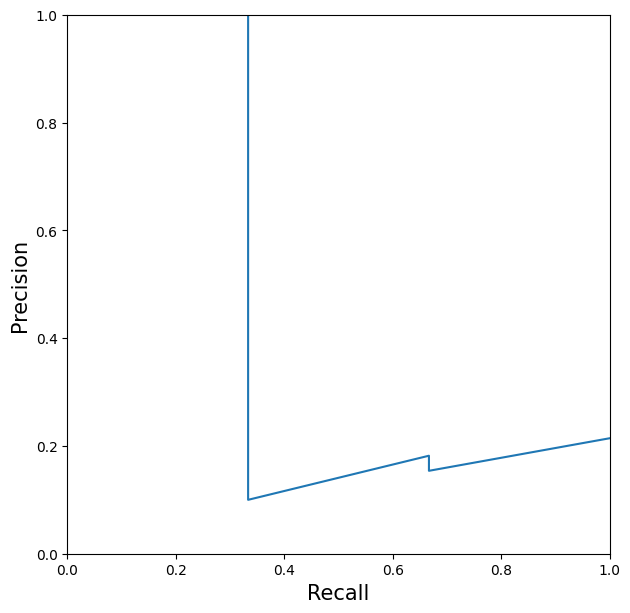

In [40]:
plt.figure(figsize=(7, 7))
plt.plot(rcl, prc)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Recall', fontsize=15)
plt.ylabel('Precision', fontsize=15)